In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages

In [5]:
load_dotenv()


True

In [6]:
checkpointer = InMemorySaver()

In [7]:
model=ChatOpenAI(
    openai_api_base="https://openrouter.ai/api/v1",
    model="openrouter/free"
)

In [8]:
model.invoke('hi')

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 45, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 32, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'poolside/laguna-s-2.1:free', 'system_fingerprint': None, 'id': 'gen-1790265038-4d7iM6tH3EYbpb3UNcga', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0d41c-a3fc-7c33-baf7-a3f89d5c457d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 

In [9]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [10]:
def chat(ChatState):
    message=ChatState['messages']
    response=model.invoke(message)

    return {'messages':[response]}

In [11]:
graph=StateGraph(ChatState)

graph.add_node('chat_node',chat)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer=checkpointer)

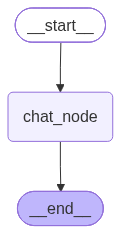

In [12]:
chatbot

In [21]:
thread_id = 1
while True:
    user_message = input("Type here:")
    print(f"User: {user_message}")

    if user_message.strip().lower() in ["exit", "bye", "quit"]:
        break

    config = {"configurable": {"thread_id": thread_id}}

    response = chatbot.invoke({"messages": [HumanMessage(content=user_message)]}, config=config)

    print(f"""Ai: {response["messages"][-1].content}""")

User: hi
Ai: Hello! 👋 It's great to hear from you. How can I help you today?
User: quit


In [ ]:
chatbot.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='who is pm of pakistan', additional_kwargs={}, response_metadata={}, id='b856a9af-0b90-4464-aa4c-99f1fe69ce53'), AIMessage(content='The current Prime Minister of Pakistan is **Shehbaz Sharif**. He assumed office on **March 4, 2024**, after winning the general elections held in February 2024. He represents the **Pakistan Muslim League – Nawaz (PML-N)** and is the brother of former Prime Minister Nawaz Sharif. This is his second term as Prime Minister, having previously served from 2017 to 2018.\n\n*Note: Political leadership can change. Please verify with the most recent and reliable sources for the latest information.*', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 209, 'prompt_tokens': 26, 'total_tokens': 235, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 76, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_to

In [ ]:
config1 = {"configurable": {"thread_id": "1"}}


initial_state = {
    'messages': [HumanMessage(content='what is you name,are you from open ai or antropic or google?')]
}
chatbot.invoke(initial_state, config=config1)

{'messages': [HumanMessage(content='who is pm of pakistan', additional_kwargs={}, response_metadata={}, id='b856a9af-0b90-4464-aa4c-99f1fe69ce53'),
  AIMessage(content='The current Prime Minister of Pakistan is **Shehbaz Sharif**. He assumed office on **March 4, 2024**, after winning the general elections held in February 2024. He represents the **Pakistan Muslim League – Nawaz (PML-N)** and is the brother of former Prime Minister Nawaz Sharif. This is his second term as Prime Minister, having previously served from 2017 to 2018.\n\n*Note: Political leadership can change. Please verify with the most recent and reliable sources for the latest information.*', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 209, 'prompt_tokens': 26, 'total_tokens': 235, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 76, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_

In [ ]:
thread_id = 1

while True:
    user_message = input("Type here: ")
    print(f"User: {user_message}")

    if user_message.strip().lower() in ["exit", "bye", "quit"]:
        break

    config = {"configurable": {"thread_id": thread_id}}

    for message_chunk, metadata in chatbot.stream(
        {"messages": [HumanMessage(content=user_message)]},
        config=config,
        stream_mode="messages"
    ):
        if message_chunk.content:
            print(
                f"AI: {message_chunk.content}",
                end="",
                flush=True
            )

User: helllo
AI: Hello Hassan!AI:  👋 ItAI: 's great to hearAI:  from you again.AI:  

I wasAI:  just thinking about ourAI:  chatAI:  earlier whereAI:  youAI:  shared thatAI:  you have some kitchenAI:  experience –AI:  IAI:  was hoping toAI:  hear howAI:  yourAI:  cookingAI:  adventures areAI:  going sinceAI:  we talkedAI:  about thatAI:  pizza recipeAI: ! 

AreAI:  you still experimentingAI:  with homemAI: ade pizza, orAI:  did you endAI:  up trying somethingAI:  differentAI:  in the kitchen latelyAI: ? I'dAI:  love to hear whatAI:  you'veAI:  been up to –AI:  whetherAI:  it's a successAI: , a "AI: learning experience," orAI:  just a questionAI:  thatAI:  cameAI:  up while cookingAI: . 

AndAI:  if you're thinkingAI:  about something completelyAI:  unrelatedAI:  to food today,AI:  that's totally fineAI:  too –AI:  IAI: 'm here forAI:  whatever'sAI:  on your mind!AI:  What wouldAI:  you like to talkAI:  about?User: my name is hasan
AI: HelloAI:  HassanAI: !AI:  👋AI:  NiceAI:  toAI:  mee

In [19]:
thread_id = 1

while True:
    user_message = input("Type here: ")
    print(f"User: {user_message}")

    if user_message.strip().lower() in ["exit", "bye", "quit"]:
        break

    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    print("AI: ", end="", flush=True)

    for message_chunk, metadata in chatbot.stream(
        {"messages": [HumanMessage(content=user_message)]},
        config=config,
        stream_mode="messages"
    ):
        if message_chunk.content:
            print(
                message_chunk.content,
                end="",
                flush=True
            )

    print()  # Move to the next line after complete response

User: hellow
AI: Hello there! 😊 

It's nice to see you again. Is there something I can help you with today? I'm here to assist with any questions you might have—whether it's about cooking, baking, recipes, or anything else you're curious about!

What's on your mind?
User: myname is hassan
AI: Hello Hassan! 👋 Nice to hear from you again.

Is there something specific I can help you with today? Whether it's about the pizza recipe we discussed earlier, another cooking question, or anything else on your mind—I'm here to help! 😊
User: what is my name?
AI: Your name is **Hassan** (you've also spelled it **Hasan** in our chat). 😊
User: quit


In [31]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages

In [32]:
class chat_state(TypedDict):
    messages :Annotated[list[BaseMessage],add_messages]


In [33]:
load_dotenv()


True

In [34]:
checkpointer=InMemorySaver()

In [45]:
graph=StateGraph(chat_state)

In [36]:
model=ChatOpenAI(
    openai_api_base="https://openrouter.ai/api/v1",
    model="openrouter/free"
)

In [48]:
def chat(state:chat_state):

    message=state['messages']

    response=model.invoke(message)
    return {'messages':[response]}


In [38]:
graph.add_node('chat_node_2',chat)
graph.add_edge(START,'chat_node_2')
graph.add_edge('chat_node_2',END)

In [39]:
chatbot=graph.compile(checkpointer=checkpointer)

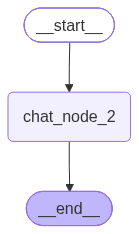

In [40]:
chatbot

In [52]:

config = {
    "configurable": {
        "thread_id": "1"
    }
}

while True:

    user_input = input("User: ")

    if user_input.lower() in ["exit", "quit"]:
        print("Chat ended.")
        break

    response = chatbot.invoke(
        {
            "messages": [HumanMessage(content=user_input)]
        },
        config=config
    )

    print("AI:", response["messages"][-1].content)


AI: Hey again! 😊 Whenever you're ready, feel free to ask me anything — whether it's a question, a task, or just a chat. I'm here to help!
AI: 

Nice to meet you, Hassan! 😊 It's great to put a name to the person behind the screen. What's on your mind today? I'm here to help with whatever you need.
AI: Your name is **Hassan**! 😊 Nice to remember, right? Is there anything else I can help you with?
Chat ended.
